# Causal MMM Framework — Feature Showcase

This notebook demonstrates the **causal** capabilities added to `mmm_framework`
across three waves of work (`critique.md` roadmap P0 → P1 → P2).

The framework's thesis: an MMM is only *causal* under assumptions + experimental
calibration. These features connect the causal **scaffolding** (DAG identification,
lift tests) to the estimation **engine**, and make the assumptions every number
rests on explicit.

| Wave | Feature | Section |
|------|---------|---------|
| P1 | Causal role typing + DAG auto-classification (confounder/mediator/collider) | §1 |
| P2 | Front-door & IV identification | §2 |
| P2 | Cross-check the graph engine vs. `networkx` | §3 |
| — | Fit a baseline Bayesian MMM (reused below) | §4 |
| P1 | Marginal-ROAS **with uncertainty** | §5 |
| P0 | Sensitivity to **unobserved confounding** (robustness value) | §6 |
| P2 | Weak-identification detection (collinear channels) | §7 |
| P2 | Geo-based identification diagnostic | §8 |
| P1 | Equifinality guardrails (data-anchored saturation) | §9 |
| P2 | Pre-specification lock + diff | §10 |
| P0 | **Experiment-calibrated priors** (the headline feature) | §11 |
| P0 | **Experiment _likelihood_ calibration** — ROAS · mROAS · extensions | §11b |
| P0 | Causal refutation suite | §12 |
| P0/P2 | Causal-assumptions reporting | §13 |

> Everything runs on small MCMC settings so the notebook executes quickly; numbers
> are illustrative, not production-grade.

## Setup

Imports and a small synthetic dataset with deliberate causal structure: a **confounder** (`Demand` drives both TV spend and Sales), two **collinear** channels (`Digital`/`Search`), and a strong, fittable trend + seasonality.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from loguru import logger
logger.remove(); logger.add(sys.stderr, level="WARNING")   # quiet framework DEBUG logs
import numpy as np
import pandas as pd

from mmm_framework.config import (
    MFFConfig, KPIConfig, MediaChannelConfig, ControlVariableConfig,
    ModelConfig, DimensionType, InferenceMethod, CausalControlRole,
)
from mmm_framework.data_loader import PanelDataset, PanelCoordinates
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

rng = np.random.default_rng(7)
periods = pd.date_range("2021-01-04", periods=60, freq="W-MON")
n = len(periods); t = np.arange(n)

# Latent demand confounds TV: marketers spend more on TV when demand is high.
demand = np.sin(2 * np.pi * t / 52) + rng.normal(0, 0.3, n)
tv      = np.abs(40 + 18 * demand + rng.normal(0, 8, n))     # confounded with demand
digital = np.abs(rng.normal(50, 12, n))
search  = np.abs(0.92 * digital + rng.normal(0, 4, n))       # collinear with Digital

y = pd.Series(
    1000 + 8.0 * t + 60 * np.sin(2 * np.pi * t / 52)          # fittable trend + seasonality
    + 1.0 * tv + 0.6 * digital + 0.5 * search                 # media effects
    + 25 * demand + rng.normal(0, 18, n),                     # confounder effect on Sales
    name="Sales",
)

config = MFFConfig(
    kpi=KPIConfig(name="Sales", dimensions=[DimensionType.PERIOD]),
    media_channels=[MediaChannelConfig(name=c, dimensions=[DimensionType.PERIOD])
                    for c in ["TV", "Digital", "Search"]],
    controls=[ControlVariableConfig(
        name="Demand", dimensions=[DimensionType.PERIOD],
        causal_role=CausalControlRole.CONFOUNDER)],   # <-- typed as a confounder (P1)
)
panel = PanelDataset(
    y=y,
    X_media=pd.DataFrame({"TV": tv, "Digital": digital, "Search": search}),
    X_controls=pd.DataFrame({"Demand": demand}),
    coords=PanelCoordinates(periods=periods, geographies=None, products=None,
                            channels=["TV", "Digital", "Search"], controls=["Demand"]),
    index=periods, config=config,
)
print(f"{n} weekly observations; channels = {panel.coords.channels}; controls = {panel.coords.controls}")

60 weekly observations; channels = ['TV', 'Digital', 'Search']; controls = ['Demand']


### Plotting setup

A shared cell for the visualizations interleaved through the showcase: `matplotlib`
for inline figures, `networkx` for the DAGs, and a consistent palette (`ACCENT`,
`ROLE_COLORS`). Every plotted value is pulled straight from the framework objects
each section already builds — nothing is recomputed by hand.

In [2]:
# ── Shared plotting setup (run once) ──
import matplotlib.pyplot as plt
import arviz as az
import networkx as nx
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
ACCENT = "#4c72b0"                                              # primary series colour
ROLE_COLORS = {"confounder": "#2ca02c", "mediator": "#d62728",  # causal-role palette
               "collider": "#ff7f0e", "precision_control": "#1f77b4"}
print("Plotting ready — matplotlib", plt.matplotlib.__version__)

Plotting ready — matplotlib 3.10.8


## §1 — Causal role typing & DAG auto-classification (P1)

Non-experts shouldn't need to know causal inference to avoid **bad controls**.
Given a DAG, `classify_dag_roles` auto-detects each control's causal role —
**confounder** (keep, un-shrunk), **mediator/collider** (refuse), **precision
control** (safe) — using the back-door criterion.

In [3]:
from mmm_framework.dag_model_builder.dag_spec import DAGSpec, DAGNode, DAGEdge, NodeType
from mmm_framework.dag_model_builder.identification import classify_dag_roles

# Demand confounds TV->Sales; Price predicts Sales only; InStore is a *consequence*
# of TV (a post-treatment mediator a naive analyst might add as a "control").
dag = DAGSpec(
    nodes=[
        DAGNode(id="sales",   variable_name="Sales",   node_type=NodeType.KPI),
        DAGNode(id="tv",      variable_name="TV",      node_type=NodeType.MEDIA),
        DAGNode(id="demand",  variable_name="Demand",  node_type=NodeType.CONTROL),
        DAGNode(id="price",   variable_name="Price",   node_type=NodeType.CONTROL),
        DAGNode(id="instore", variable_name="InStore", node_type=NodeType.CONTROL),
    ],
    edges=[
        DAGEdge(source="tv", target="sales"),
        DAGEdge(source="demand", target="tv"), DAGEdge(source="demand", target="sales"),
        DAGEdge(source="price", target="sales"),
        DAGEdge(source="tv", target="instore"), DAGEdge(source="instore", target="sales"),
    ],
)
cls = classify_dag_roles(dag, treatment_ids=["tv"], outcome_id="sales",
                         control_ids=["demand", "price", "instore"])
pd.DataFrame([{"control": v, "role": cls.role_for(i)[0], "why": cls.role_for(i)[1]}
              for i, v in [("demand", "Demand"), ("price", "Price"), ("instore", "InStore")]])

,control,role,why
0,Demand,confounder,it is a common cause of media and the KPI (bac...
1,Price,precision_control,"it predicts the KPI but is not a common cause,..."
2,InStore,mediator,it is a consequence of media 'tv' (post-treatm...


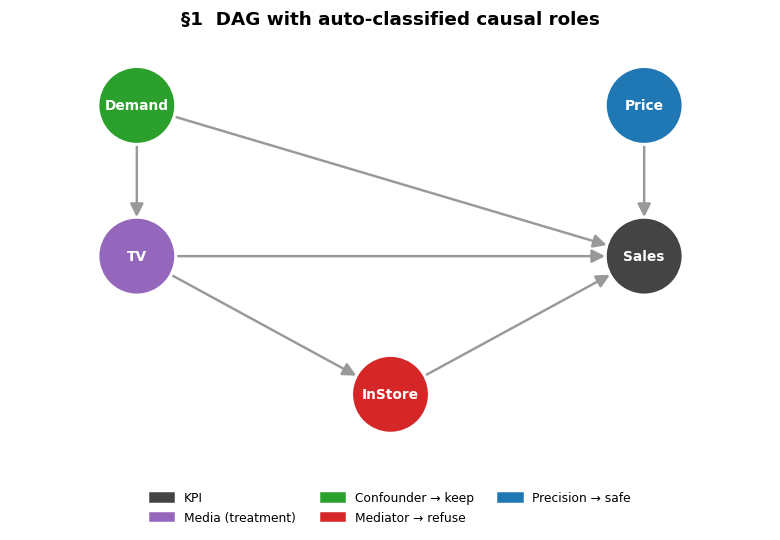

In [4]:
# ── §1 visualization: the DAG, nodes auto-coloured by their classified causal role ──
G = nx.DiGraph([(e.source, e.target) for e in dag.edges])
pos = {"demand": (0, 1.2), "tv": (0, 0), "sales": (2, 0), "price": (2, 1.2), "instore": (1, -1.1)}
def _ncolor(nd):
    if nd.node_type == NodeType.KPI:   return "#444444"
    if nd.node_type == NodeType.MEDIA: return "#9467bd"
    return ROLE_COLORS.get(cls.role_for(nd.id)[0], "#cccccc")
order  = [nd.id for nd in dag.nodes]
colors = [_ncolor(nd) for nd in dag.nodes]
labels = {nd.id: nd.variable_name for nd in dag.nodes}
fig, ax = plt.subplots(figsize=(7.2, 5))
nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle="-|>", arrowsize=18,
                       edge_color="#999", width=1.6, node_size=2600)
nx.draw_networkx_nodes(G, pos, nodelist=order, node_color=colors, node_size=2600,
                       edgecolors="white", linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_color="white",
                        font_size=9, font_weight="bold", ax=ax)
ax.legend(handles=[Patch(color=c, label=l) for l, c in [
        ("KPI", "#444444"), ("Media (treatment)", "#9467bd"),
        ("Confounder → keep", ROLE_COLORS["confounder"]),
        ("Mediator → refuse", ROLE_COLORS["mediator"]),
        ("Precision → safe", ROLE_COLORS["precision_control"])]],
    loc="lower center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=8, frameon=False)
ax.set_title("§1  DAG with auto-classified causal roles", fontweight="bold")
ax.axis("off"); ax.margins(0.18); plt.tight_layout(); plt.show()

The model then **refuses to fit** when a mediator/collider is used as a control — a loud failure beats a silently biased number:

In [5]:
mediator_cfg = MFFConfig(
    kpi=KPIConfig(name="Sales", dimensions=[DimensionType.PERIOD]),
    media_channels=[MediaChannelConfig(name="TV", dimensions=[DimensionType.PERIOD])],
    controls=[ControlVariableConfig(name="InStore", dimensions=[DimensionType.PERIOD],
                                    causal_role=CausalControlRole.MEDIATOR)],
)
pp = pd.date_range("2021-01-04", periods=20, freq="W-MON")
bad_panel = PanelDataset(
    y=pd.Series(100 + rng.normal(0, 5, 20), name="Sales"),
    X_media=pd.DataFrame({"TV": np.abs(rng.normal(100, 30, 20))}),
    X_controls=pd.DataFrame({"InStore": rng.normal(0, 1, 20)}),
    coords=PanelCoordinates(periods=pp, geographies=None, products=None,
                            channels=["TV"], controls=["InStore"]),
    index=pp, config=mediator_cfg,
)
try:
    BayesianMMM(bad_panel, ModelConfig(inference_method=InferenceMethod.BAYESIAN_PYMC))
except ValueError as e:
    print("Refused (correctly):\n", str(e)[:280])

Refused (correctly):
 Refusing to condition on post-treatment / collider variables used as controls: 'InStore' [mediator]. Conditioning on a mediator blocks part of the media effect, and conditioning on a collider opens a spurious path -- either biases a total-effect estimate. Remove these from `contr


## §2 — Front-door & IV identification (P2)

Beyond back-door adjustment, the identification layer now checks Pearl's
**front-door** criterion (for mediation models) and the **instrumental-variable**
criterion (when an exogenous instrument is declared). These are identification
*checks* that inform reasoning/reporting — they do not change the likelihood.

In [6]:
from mmm_framework.dag_model_builder.identification import frontdoor_criterion, iv_criterion

def spec(nodes, edges):
    return DAGSpec(nodes=[DAGNode(id=i, variable_name=i.upper(), node_type=ty)
                          for i, ty in nodes.items()],
                   edges=[DAGEdge(source=s, target=d) for s, d in edges])

# Front door: TV -> Awareness -> Sales, with unobserved U confounding TV and Sales.
fd = frontdoor_criterion(
    spec({"tv": NodeType.MEDIA, "aware": NodeType.MEDIATOR, "sales": NodeType.KPI, "u": NodeType.CONTROL},
         [("tv", "aware"), ("aware", "sales"), ("u", "tv"), ("u", "sales")]),
    "tv", ["aware"], "sales")

# IV: PolicyShock -> TV -> Sales (valid) vs. an exclusion-violating variant.
iv_ok  = iv_criterion(spec({"z": NodeType.INSTRUMENT, "tv": NodeType.MEDIA, "sales": NodeType.KPI, "u": NodeType.CONTROL},
                           [("z", "tv"), ("tv", "sales"), ("u", "tv"), ("u", "sales")]), "z", "tv", "sales")
iv_bad = iv_criterion(spec({"z": NodeType.INSTRUMENT, "tv": NodeType.MEDIA, "sales": NodeType.KPI, "u": NodeType.CONTROL},
                           [("z", "tv"), ("tv", "sales"), ("z", "sales"), ("u", "tv"), ("u", "sales")]), "z", "tv", "sales")

print(f"Front-door identified (TV->Awareness->Sales despite U): {fd.identifiable}")
print(f"IV valid (Z->TV->Sales):                                {iv_ok.identifiable}")
print(f"IV valid when Z also -> Sales (exclusion violated):     {iv_bad.identifiable}")

Front-door identified (TV->Awareness->Sales despite U): True
IV valid (Z->TV->Sales):                                True
IV valid when Z also -> Sales (exclusion violated):     False


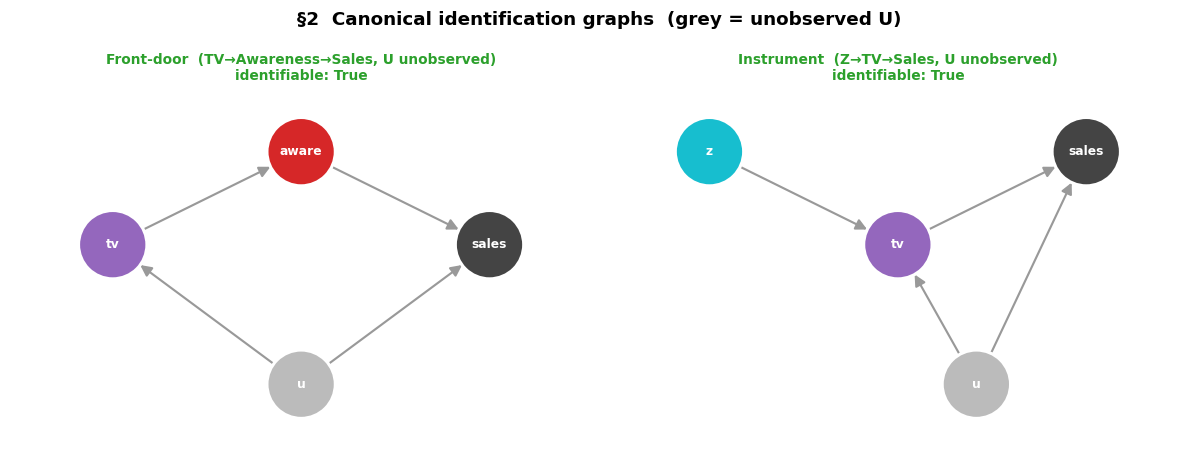

In [7]:
# ── §2 visualization: the canonical front-door and instrument graphs ──
def _draw(ax, edges, pos, kinds, title, ok):
    g = nx.DiGraph(edges)
    cmap = {"media": "#9467bd", "mediator": ROLE_COLORS["mediator"],
            "kpi": "#444444", "iv": "#17becf", "u": "#bbbbbb"}
    nodes = list(pos)
    nx.draw_networkx_edges(g, pos, ax=ax, arrowstyle="-|>", arrowsize=15,
                           edge_color="#999", width=1.4, node_size=2000)
    nx.draw_networkx_nodes(g, pos, nodelist=nodes, node_size=2000, ax=ax,
                           node_color=[cmap[kinds[k]] for k in nodes],
                           edgecolors="white", linewidths=2)
    nx.draw_networkx_labels(g, pos, font_color="white", font_size=8, font_weight="bold", ax=ax)
    ax.set_title(f"{title}\nidentifiable: {ok}", fontsize=9,
                 color=("#2ca02c" if ok else "#d62728"), fontweight="bold")
    ax.axis("off"); ax.margins(0.2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
_draw(axes[0], [("tv", "aware"), ("aware", "sales"), ("u", "tv"), ("u", "sales")],
      {"tv": (0, 0), "aware": (1, 0.6), "sales": (2, 0), "u": (1, -0.9)},
      {"tv": "media", "aware": "mediator", "sales": "kpi", "u": "u"},
      "Front-door  (TV→Awareness→Sales, U unobserved)", fd.identifiable)
_draw(axes[1], [("z", "tv"), ("tv", "sales"), ("u", "tv"), ("u", "sales")],
      {"z": (-0.2, 0.6), "tv": (1, 0), "sales": (2.2, 0.6), "u": (1.5, -0.9)},
      {"z": "iv", "tv": "media", "sales": "kpi", "u": "u"},
      "Instrument  (Z→TV→Sales, U unobserved)", iv_ok.identifiable)
fig.suptitle("§2  Canonical identification graphs  (grey = unobserved U)", fontweight="bold")
plt.tight_layout(); plt.show()

## §3 — Cross-checking the hand-rolled graph engine (P2)

The back-door/front-door/IV checks all rest on a hand-rolled d-separation engine.
We validate it against `networkx` for **every** conditioning set on a battery of
DAGs (here: one example).

In [8]:
import networkx as nx
from itertools import chain, combinations
from mmm_framework.dag_model_builder.identification import (
    _all_simple_paths, _path_blocked_by, BackdoorPath)

mbias = spec({"t": NodeType.MEDIA, "y": NodeType.KPI, "a": NodeType.CONTROL,
              "b": NodeType.CONTROL, "c": NodeType.CONTROL},
             [("a", "t"), ("a", "c"), ("b", "c"), ("b", "y"), ("t", "y")])  # classic M-bias
g = nx.DiGraph([(e.source, e.target) for e in mbias.edges])

def ours_dsep(s, x, y, z):
    for p in _all_simple_paths(s, x, y):
        bp = BackdoorPath(nodes=[x] + [nn for nn, _ in p], edge_dirs=[d for _, d in p])
        if not _path_blocked_by(bp, set(z), s):
            return False
    return True

others = ["a", "b", "c"]
agree = all(
    ours_dsep(mbias, "t", "y", set(zz)) == nx.is_d_separator(g, {"t"}, {"y"}, set(zz))
    for zz in chain.from_iterable(combinations(others, r) for r in range(len(others) + 1))
)
print(f"M-bias DAG: our d-separation matches networkx for ALL conditioning sets: {agree}")

M-bias DAG: our d-separation matches networkx for ALL conditioning sets: True


## §4 — Fit a baseline Bayesian MMM

One small fit, **reused** by every model-dependent demo below.

In [9]:
model = BayesianMMM(
    panel,
    ModelConfig(inference_method=InferenceMethod.BAYESIAN_PYMC,
                n_chains=4, n_draws=1000, n_tune=500, target_accept=0.92),
    TrendConfig(type=TrendType.LINEAR),
)
results = model.fit(random_seed=0)
r2 = float(np.corrcoef(model.predict(random_seed=0).y_pred_mean, y.values)[0, 1] ** 2)
print(f"Fitted. In-sample R^2 ~ {r2:.3f}")

Sampling: [adstock_Digital, adstock_Search, adstock_TV, beta_Digital, beta_Search, beta_TV, beta_controls, intercept, sat_lam_Digital, sat_lam_Search, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Digital, sat_lam_Digital, beta_Digital, adstock_Search, sat_lam_Search, beta_Search, beta_controls, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 21 seconds.
There were 29 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [y_obs]


Output()

Fitted. In-sample R^2 ~ 0.924


Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

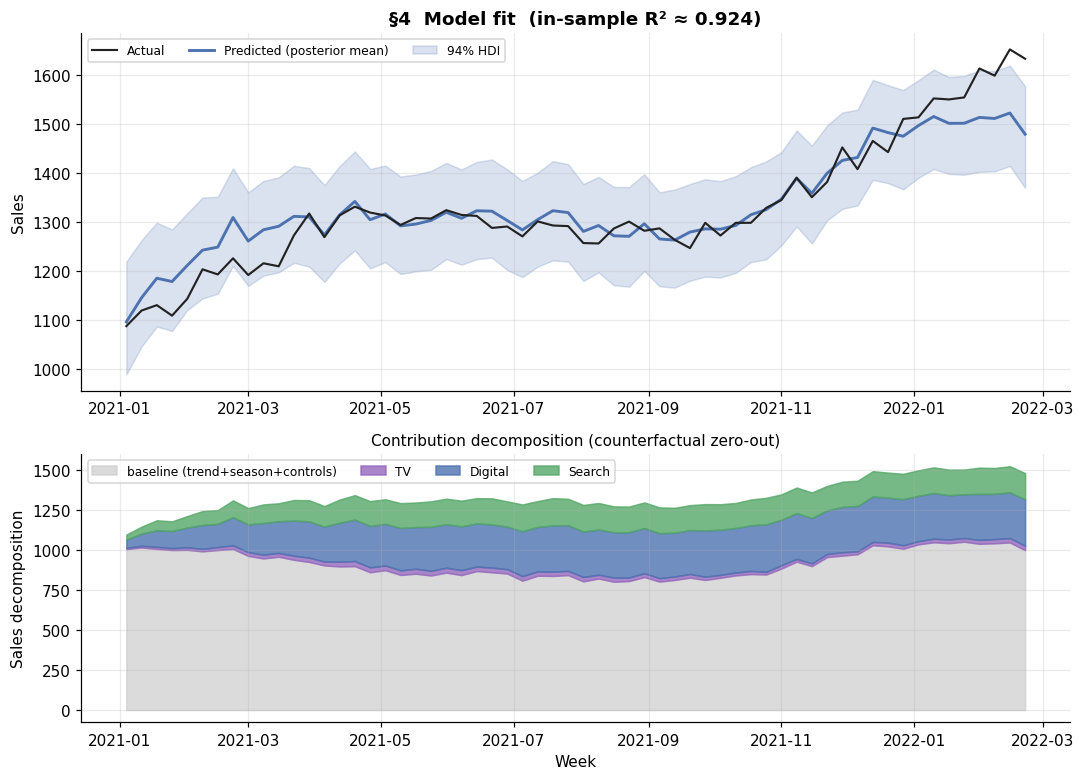

In [10]:
# ── §4 visualization: posterior fit + 94% HDI (top) and contribution decomposition (bottom) ──
pred = model.predict(random_seed=0)
contrib = model.compute_counterfactual_contributions().channel_contributions
fig, axes = plt.subplots(2, 1, figsize=(10, 7.2), gridspec_kw={"height_ratios": [2, 1.5]})
ax = axes[0]
ax.plot(periods, y.values, color="#222", lw=1.4, label="Actual", zorder=3)
ax.plot(periods, pred.y_pred_mean, color=ACCENT, lw=1.9, label="Predicted (posterior mean)")
ax.fill_between(periods, pred.y_pred_hdi_low, pred.y_pred_hdi_high,
                color=ACCENT, alpha=0.20, label="94% HDI")
ax.set_ylabel("Sales"); ax.legend(loc="upper left", fontsize=8, ncol=3)
ax.set_title(f"§4  Model fit  (in-sample R² ≈ {r2:.3f})", fontweight="bold")
ax = axes[1]
base = pred.y_pred_mean - contrib.sum(axis=1).values
ax.fill_between(periods, 0, base, color="#cccccc", alpha=0.7,
                label="baseline (trend+season+controls)")
cum = base.copy()
for col, c in zip(contrib.columns, ["#9467bd", "#4c72b0", "#55a868"]):
    ax.fill_between(periods, cum, cum + contrib[col].values, alpha=0.8, color=c, label=col)
    cum = cum + contrib[col].values
ax.set_ylabel("Sales decomposition"); ax.set_xlabel("Week")
ax.legend(loc="upper left", fontsize=8, ncol=4)
ax.set_title("Contribution decomposition (counterfactual zero-out)", fontsize=10)
plt.tight_layout(); plt.show()

## §5 — Marginal-ROAS **with uncertainty** (P1)

The headline efficiency number is no longer a bare point estimate: marginal ROAS
now carries a credible interval, propagated per-draw through the posterior.

In [11]:
mc = model.compute_marginal_contributions(spend_increase_pct=10.0, hdi_prob=0.9, random_seed=0)
mc.round(3)

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

,Channel,Current Spend,Spend Increase (10.0%),Marginal Contribution,Marginal ROAS,Marginal Contribution HDI Low,Marginal Contribution HDI High,Marginal ROAS HDI Low,Marginal ROAS HDI High
0,TV,2348.949,234.895,111.299,0.474,5.652,307.247,0.024,1.308
1,Digital,2828.692,282.869,1123.668,3.972,254.266,1862.138,0.899,6.583
2,Search,2587.099,258.710,645.209,2.494,53.355,1516.785,0.206,5.863


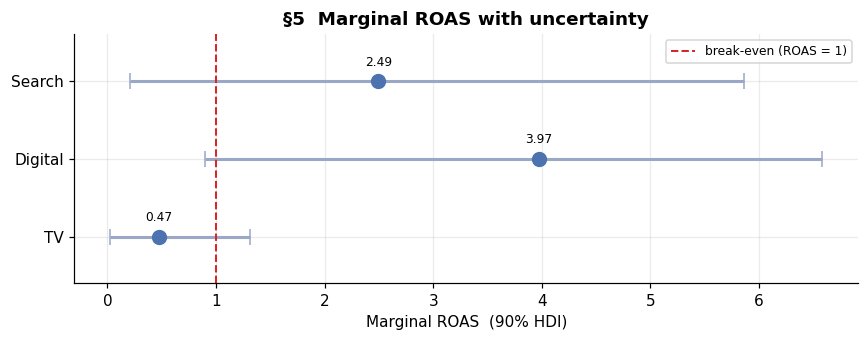

In [12]:
# ── §5 visualization: marginal-ROAS forest plot with 90% HDI and the break-even line ──
chans = mc["Channel"].tolist()
roas  = mc["Marginal ROAS"].values
lo_   = mc["Marginal ROAS HDI Low"].values
hi_   = mc["Marginal ROAS HDI High"].values
ypos  = np.arange(len(chans))
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.errorbar(roas, ypos, xerr=[roas - lo_, hi_ - roas], fmt="o", color=ACCENT,
            capsize=5, markersize=9, lw=2, ecolor="#9aa7c7")
ax.axvline(1.0, ls="--", color="#d62728", lw=1.3, label="break-even (ROAS = 1)")
for yy, r in zip(ypos, roas):
    ax.annotate(f"{r:.2f}", (r, yy), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)
ax.set_yticks(ypos); ax.set_yticklabels(chans); ax.set_ylim(-0.6, len(chans) - 0.4)
ax.set_xlabel("Marginal ROAS  (90% HDI)")
ax.set_title("§5  Marginal ROAS with uncertainty", fontweight="bold")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## §6 — Sensitivity to unobserved confounding (P0)

No adjustment set can remove an *unobserved* confounder (e.g. latent demand). The
**robustness value** is the share of variance a hidden confounder would need to
explain in both a channel's spend and the KPI to nullify its effect. Low = fragile.

In [13]:
from mmm_framework.validation import UnobservedConfoundingAnalysis
sens = UnobservedConfoundingAnalysis(model).run()
print("Fragile channels (could be overturned by a weak confounder):", sens.fragile_channels)
sens.summary()

Fragile channels (could be overturned by a weak confounder): []


,Channel,Estimate,t-value,Partial R²,Robustness Value,Fragile
0,TV,1.162,1.38,0.033,0.170,No
1,Digital,5.568,2.22,0.082,0.258,No
2,Search,3.369,1.49,0.039,0.182,No


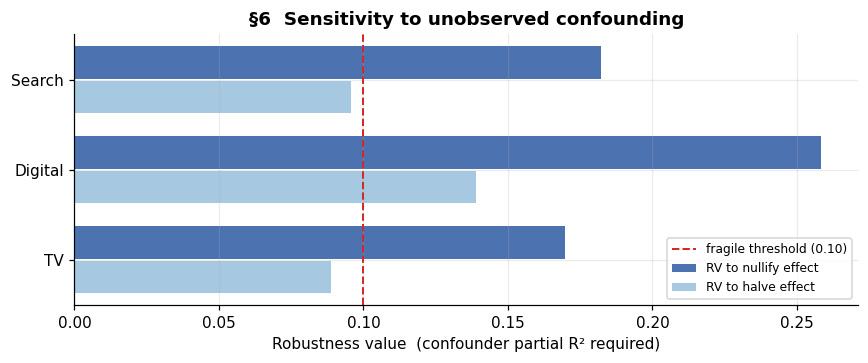

In [14]:
# ── §6 visualization: robustness values (to nullify and to halve) vs the fragile threshold ──
chans = [c.channel for c in sens.channels]
rv    = [c.robustness_value for c in sens.channels]
rvh   = [c.robustness_value_half for c in sens.channels]
ypos  = np.arange(len(chans))
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(ypos + 0.19, rv, height=0.36, label="RV to nullify effect",
        color=["#d62728" if c.is_fragile else ACCENT for c in sens.channels])
ax.barh(ypos - 0.19, rvh, height=0.36, color="#a6c8e0", label="RV to halve effect")
ax.axvline(0.10, ls="--", color="#d62728", lw=1.3, label="fragile threshold (0.10)")
ax.set_yticks(ypos); ax.set_yticklabels(chans)
ax.set_xlabel("Robustness value  (confounder partial R² required)")
ax.set_title("§6  Sensitivity to unobserved confounding", fontweight="bold")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

## §7 — Weak-identification detection (P2)

`Digital` and `Search` move together, so the data cannot separate their individual
ROIs regardless of confounding. The diagnostic detects the collinear cluster, the
ill-conditioned design, and recommends a grouped prior — **reporting only**.

In [15]:
from mmm_framework.validation.channel_diagnostics import ChannelDiagnostics
cd = ChannelDiagnostics(model).run_all()
print("Collinear clusters:")
for cl in cd.collinear_clusters:
    print(f"  {cl.channels}  (|r| up to {cl.max_correlation:.2f})")
print(f"Design condition number: {cd.condition_number:.1f}")
print("Recommendations:")
for r in cd.grouped_prior_recommendations:
    print(" -", r)

Collinear clusters:
  ['Digital', 'Search']  (|r| up to 0.93)
Design condition number: 33.0
Recommendations:
 - Channels ['Digital', 'Search'] are collinear -- consider a grouped prior (shared group-level scale) or report their combined effect rather than overconfident per-channel ROIs.


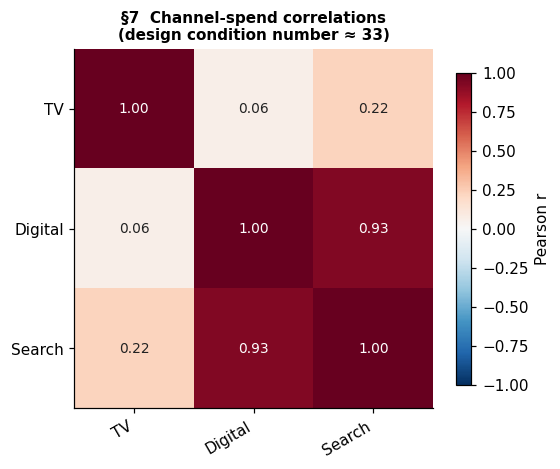

In [16]:
# ── §7 visualization: channel-spend correlation heatmap (Digital/Search are collinear) ──
corr  = cd.correlation_matrix
M     = corr.values
names = list(corr.columns)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(M[i, j]) > 0.55 else "#222")
fig.colorbar(im, ax=ax, shrink=0.82, label="Pearson r")
ax.grid(False)
ax.set_title(f"§7  Channel-spend correlations\n(design condition number ≈ {cd.condition_number:.0f})",
             fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

## §8 — Geo-based identification diagnostic (P2)

Cross-geo spend variation is quasi-experimental signal — but only if it exists and
is exogenous. This *necessary-not-sufficient* diagnostic reports whether each
channel has enough cross-geo variation to support geo-level inference.

In [17]:
from types import SimpleNamespace
from mmm_framework.validation import geo_spend_variation_diagnostic

# A small constructed multi-geo model (3 geos): TV varies across geos, Radio is uniform.
geo_spend = {"TV": [100., 500., 60.], "Radio": [100., 100., 100.]}
rows, gidx = [], []
for gg in range(3):
    for _ in range(12):
        gidx.append(gg); rows.append([geo_spend[c][gg] for c in geo_spend])
geo_model = SimpleNamespace(has_geo=True, n_geos=3, geo_idx=np.array(gidx),
                            X_media_raw=np.array(rows, float), channel_names=list(geo_spend))
diag = geo_spend_variation_diagnostic(geo_model)
display(pd.DataFrame([c.to_dict() for c in diag.channels]).round(3))
print("Channels with too little geo variation:", diag.weak_channels)
print("\nCaveat:", diag.caveat)

,channel,cv_across_geos,sufficient
0,TV,0.903,True
1,Radio,0.000,False


Channels with too little geo variation: ['Radio']

Caveat: Cross-geo spend variation identifies effects only if geo-level spend is exogenous -- not the result of targeting higher-demand geographies. Where spend follows local demand, geo variation does NOT remove unobserved-demand confounding; anchor geo-level claims with a randomized geo-lift experiment.


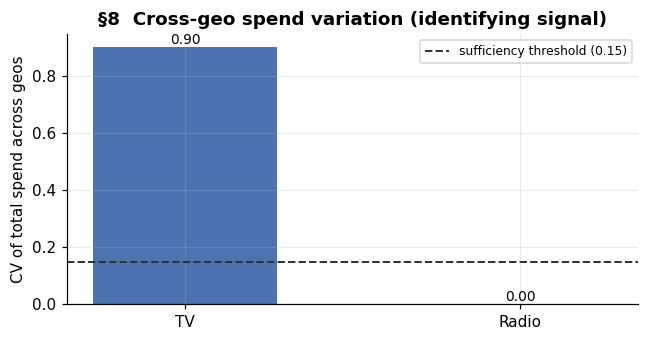

In [18]:
# ── §8 visualization: cross-geo spend variation vs the sufficiency threshold ──
chans = [c.channel for c in diag.channels]
cvs   = [c.cv_across_geos for c in diag.channels]
cols  = ["#d62728" if not c.sufficient else ACCENT for c in diag.channels]
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.bar(chans, cvs, color=cols, width=0.55)
ax.axhline(diag.cv_threshold, ls="--", color="#333", lw=1.3,
           label=f"sufficiency threshold ({diag.cv_threshold:g})")
for b, v in zip(bars, cvs):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("CV of total spend across geos")
ax.set_title("§8  Cross-geo spend variation (identifying signal)", fontweight="bold")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## §9 — Equifinality guardrails (P1)

Adstock decay, saturation, and the coefficient trade off against one another
(`normalize=True` folds magnitude into β). One mitigation: anchor the Hill
half-saturation `kappa` to the data's own spend percentiles instead of letting it
extrapolate.

In [19]:
from mmm_framework.config import SaturationConfig
lo, hi = SaturationConfig.compute_kappa_bounds_from_data(tv, percentiles=(0.1, 0.9))
print(f"Data-anchored kappa bounds for TV (10th-90th pct of spend): [{lo:.1f}, {hi:.1f}]")
print("Pass these as kappa_lower/kappa_upper to bound the Hill prior to the data's support.")

Data-anchored kappa bounds for TV (10th-90th pct of spend): [19.8, 58.8]
Pass these as kappa_lower/kappa_upper to bound the Hill prior to the data's support.


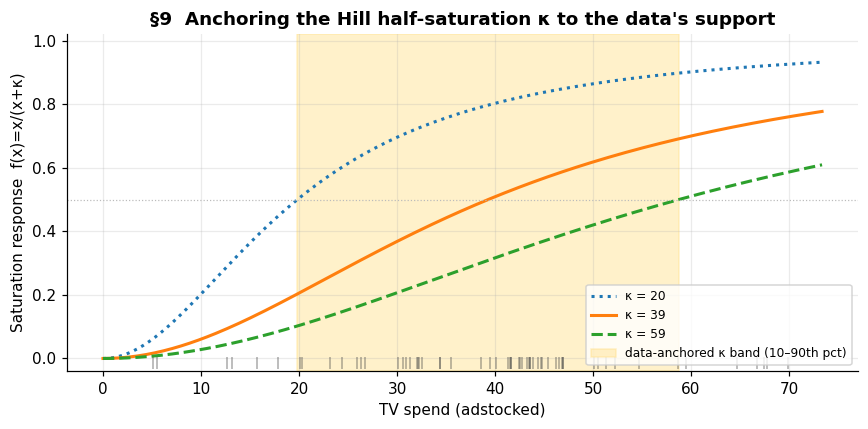

In [20]:
# ── §9 visualization: Hill curves across the data-anchored κ band, with a spend rug ──
lo_k, hi_k = SaturationConfig.compute_kappa_bounds_from_data(tv, percentiles=(0.1, 0.9))
xs = np.linspace(0, tv.max() * 1.05, 250)
fig, ax = plt.subplots(figsize=(8, 4))
for kappa, style in [(lo_k, ":"), ((lo_k + hi_k) / 2, "-"), (hi_k, "--")]:
    ax.plot(xs, xs**2 / (xs**2 + kappa**2), style, lw=2, label=f"κ = {kappa:.0f}")
ax.axvspan(lo_k, hi_k, color="#ffe08a", alpha=0.45, label="data-anchored κ band (10–90th pct)")
ax.plot(tv, np.full_like(tv, -0.015), "|", color="#444", alpha=0.45, ms=8)
ax.axhline(0.5, color="#bbb", lw=0.8, ls=":")
ax.set_xlabel("TV spend (adstocked)"); ax.set_ylabel("Saturation response  f(x)=x/(x+κ)")
ax.set_ylim(-0.04, 1.02)
ax.set_title("§9  Anchoring the Hill half-saturation κ to the data's support", fontweight="bold")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

## §10 — Pre-specification lock + diff (P2)

Pre-registration is only meaningful if divergences are *detected*. `diff_spec`
compares a locked spec to the current one, identity-keyed so reordering isn't a
false alarm but a re-labelled confounder or an added channel is caught.

In [21]:
from mmm_framework.config import diff_spec, summarize_spec_diff

frozen = {"media_channels": [{"name": "TV", "adstock": {"l_max": 8}}, {"name": "Digital"}],
          "controls": [{"name": "Demand", "causal_role": "confounder"}], "model": {"n_draws": 2000}}
current = {"media_channels": [{"name": "Digital"}, {"name": "TV", "adstock": {"l_max": 13}}, {"name": "Search"}],
           "controls": [{"name": "Demand", "causal_role": "precision_control"}], "model": {"n_draws": 2000}}
print(summarize_spec_diff(diff_spec(frozen, current)))

3 divergence(s) from the pre-registered specification:
  ~ controls[name=Demand].causal_role: 'confounder' → 'precision_control'
  + media_channels[name=Search].name = 'Search' (added)
  ~ media_channels[name=TV].adstock.l_max: 8 → 13


## §11 — Experiment-calibrated priors (P0) — the headline feature

The single most important lever for causal validity: fold a randomized **lift /
incrementality** result into an informative prior on a channel's coefficient, so
the observational model is *anchored* to experimental evidence (which estimates the
causal effect despite unobserved demand). Two-stage flow: **fit → derive prior →
refit**.

In [22]:
from mmm_framework.calibration import calibrate_with_experiments
from mmm_framework.validation import LiftTestResult

base_tv = float(model.compute_counterfactual_contributions(channels=["TV"]).total_contributions["TV"])
# Pretend a geo-lift experiment measured TV as ~1.6x as effective as the baseline fit.
measured, lift_se = 1.6 * base_tv, 0.10 * abs(1.6 * base_tv)
lift = LiftTestResult("TV", (str(periods[0].date()), str(periods[-1].date())), measured, lift_se)

outcome = calibrate_with_experiments(model, [lift], refit=True,
                                     draws=1000, tune=1000, chains=4, random_seed=0)
cal = outcome.report.channel_calibrations[0]
print(f"Calibrated channels: {outcome.report.calibrated_channels}")
print(f"  baseline-fit beta mean : {cal.beta_fit_mean:.3f}")
print(f"  experiment-implied beta: {cal.beta_target:.3f}  (the prior now anchors the refit)")
new_tv = float(outcome.model.compute_counterfactual_contributions(channels=['TV']).total_contributions['TV'])
print(f"\nTV contribution  baseline={base_tv:.0f}  ->  experiment={measured:.0f}  ->  refit={new_tv:.0f}")
print("The refit moved toward the experimental value.")

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [adstock_Digital, adstock_Search, adstock_TV, beta_Digital, beta_Search, beta_TV, beta_controls, intercept, sat_lam_Digital, sat_lam_Search, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Digital, sat_lam_Digital, beta_Digital, adstock_Search, sat_lam_Search, beta_Search, beta_controls, sigma]


...

Output()

Calibrated channels: ['TV']
  baseline-fit beta mean : 1.162
  experiment-implied beta: 1.460  (the prior now anchors the refit)


Sampling: [y_obs]


Output()


TV contribution  baseline=1389  ->  experiment=2223  ->  refit=1693
The refit moved toward the experimental value.


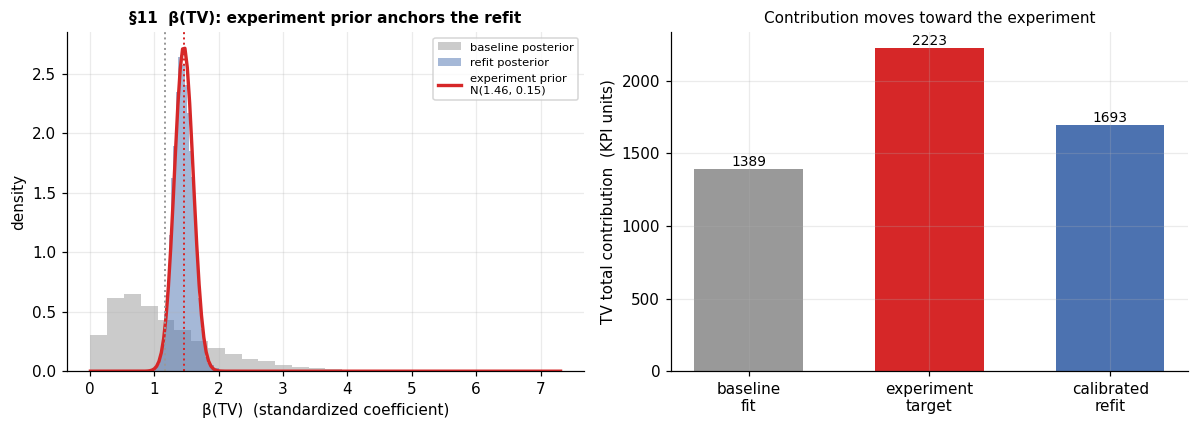

In [23]:
# ── §11 visualization: experiment prior anchors the refit (β coefficient scale, left);
#    the resulting TV contribution shift (KPI scale, right) ──
beta_base  = model._trace.posterior["beta_TV"].values.flatten()
beta_refit = outcome.model._trace.posterior["beta_TV"].values.flatten()
mu, sd = cal.beta_target, cal.beta_sigma
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.hist(beta_base, bins=28, density=True, alpha=0.5, color="#999", label="baseline posterior")
ax.hist(beta_refit, bins=28, density=True, alpha=0.5, color=ACCENT, label="refit posterior")
gx = np.linspace(min(beta_base.min(), mu - 3 * sd), max(beta_base.max(), mu + 3 * sd), 200)
ax.plot(gx, np.exp(-0.5 * ((gx - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi)),
        color="#d62728", lw=2.2, label=f"experiment prior\nN({mu:.2f}, {sd:.2f})")
ax.axvline(cal.beta_fit_mean, color="#999", ls=":", lw=1.3)
ax.axvline(mu, color="#d62728", ls=":", lw=1.3)
ax.set_xlabel("β(TV)  (standardized coefficient)"); ax.set_ylabel("density")
ax.set_title("§11  β(TV): experiment prior anchors the refit", fontweight="bold", fontsize=10)
ax.legend(fontsize=7.5)
ax = axes[1]
vals = [base_tv, measured, new_tv]
labs = ["baseline\nfit", "experiment\ntarget", "calibrated\nrefit"]
bars = ax.bar(labs, vals, color=["#999", "#d62728", ACCENT], width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("TV total contribution  (KPI units)")
ax.set_title("Contribution moves toward the experiment", fontsize=10)
plt.tight_layout(); plt.show()

## §11b — Experiment **likelihood** calibration (NEW) — ROAS, mROAS & joint anchoring

§11 turned the experiment into a *prior* on the coefficient β: it inverts a measured **contribution** to
a target on β and holds the saturation/adstock shape fixed. The newer route folds the experiment **into
the likelihood** — the measured value becomes a data point whose model expectation is the channel's
*estimand*, so a single fit updates **β, the s-curve, _and_ the adstock kernel jointly**, and it
generalizes beyond contributions to **ROAS** and **marginal ROAS** (which a coefficient prior cannot
express). The same one-line API works on the extension models too.

| | Prior route (§11) | Likelihood route (§11b) |
|---|---|---|
| how | derive a Gamma prior on β, **refit** | add an in-graph likelihood term, **one fit** |
| estimands | contribution only | **contribution · ROAS · mROAS** |
| updates | β (shape held fixed) | **β + saturation + adstock, jointly** |
| models | core | **core · nested · multivariate · combined** |

The call is just `BayesianMMM(..., experiments=[ExperimentMeasurement(...)])` (or
`model.add_experiment_calibration([...])`).

In [24]:
from mmm_framework.calibration import ExperimentMeasurement, ExperimentEstimand

period = (str(periods[0].date()), str(periods[-1].date()))
tv_spend      = float(panel.X_media["TV"].sum())
base_roas     = base_tv / tv_spend           # the §4 model's implied TV ROAS
measured_roas = measured / tv_spend          # the same geo-lift, expressed as a ROAS

# Fold the experiment straight into the graph as a likelihood on TV's ROAS.
roas_exp = ExperimentMeasurement("TV", period, value=measured_roas, se=0.10 * measured_roas,
                                 estimand=ExperimentEstimand.ROAS)
model_lik = BayesianMMM(
    panel,
    ModelConfig(inference_method=InferenceMethod.BAYESIAN_PYMC,
                n_chains=4, n_draws=1000, n_tune=500, target_accept=0.92),
    TrendConfig(type=TrendType.LINEAR),
    experiments=[roas_exp],                  # <-- the only change vs §4
)
model_lik.fit(draws=1000, tune=1000, chains=4, cores=4, random_seed=0)

# The graph now carries the experiment node AND a deterministic of the model-implied
# estimand — "what the model thinks the experiment should have measured".
est_var  = next(v for v in model_lik._trace.posterior.data_vars if str(v).endswith("model_estimand"))
implied  = model_lik._trace.posterior[est_var].values.flatten()
new_tv_lik = float(model_lik.compute_counterfactual_contributions(channels=["TV"]).total_contributions["TV"])
print(f"in-graph estimand node : {est_var}")
print(f"TV ROAS (model-implied): uncalibrated ≈ {base_roas:.2f}  ->  calibrated {implied.mean():.2f}"
      f"   (measured {measured_roas:.2f})")
print(f"TV contribution        : {base_tv:.0f}  ->  {new_tv_lik:.0f}   (anchored to the experiment)")

Sampling: [adstock_Digital, adstock_Search, adstock_TV, beta_Digital, beta_Search, beta_TV, beta_controls, experiment_TV_roas_0, intercept, sat_lam_Digital, sat_lam_Search, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Digital, sat_lam_Digital, beta_Digital, adstock_Search, sat_lam_Search, beta_Search, beta_controls, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.
There were 15 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

in-graph estimand node : experiment_TV_roas_0_model_estimand
TV ROAS (model-implied): uncalibrated ≈ 0.59  ->  calibrated 0.93   (measured 0.95)
TV contribution        : 1389  ->  2181   (anchored to the experiment)


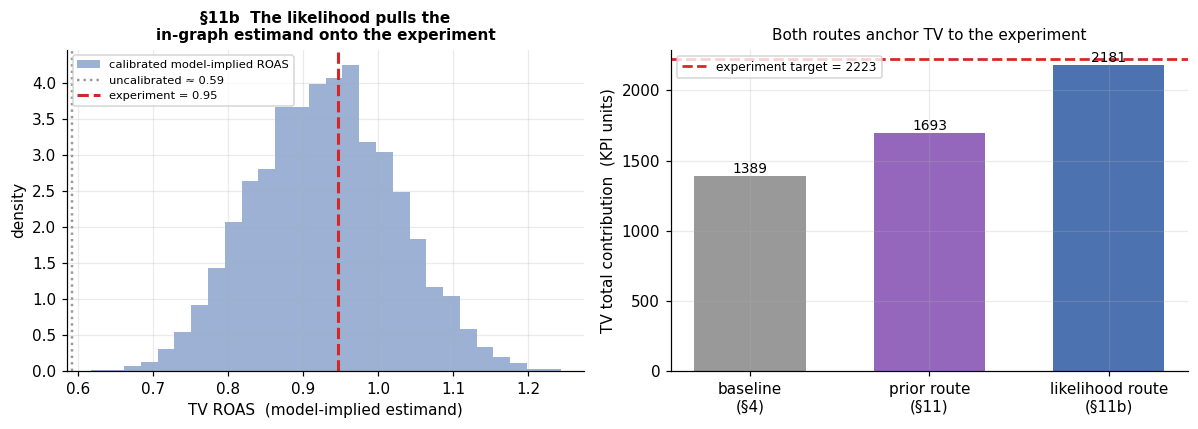

In [25]:
# ── §11b visualization: the in-graph estimand is pulled onto the experiment (left);
#    both calibration routes move TV's contribution toward the measured value (right) ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(implied, bins=28, density=True, color=ACCENT, alpha=0.55, label="calibrated model-implied ROAS")
ax.axvline(base_roas, color="#999", ls=":", lw=1.6, label=f"uncalibrated ≈ {base_roas:.2f}")
ax.axvline(measured_roas, color="#d62728", ls="--", lw=2.0, label=f"experiment = {measured_roas:.2f}")
ax.set_xlabel("TV ROAS  (model-implied estimand)"); ax.set_ylabel("density")
ax.set_title("§11b  The likelihood pulls the\nin-graph estimand onto the experiment",
             fontweight="bold", fontsize=10)
ax.legend(fontsize=7.5)

ax = axes[1]
vals = [base_tv, new_tv, new_tv_lik]
labs = ["baseline\n(§4)", "prior route\n(§11)", "likelihood route\n(§11b)"]
bars = ax.bar(labs, vals, color=["#999", "#9467bd", ACCENT], width=0.62)
ax.axhline(measured, color="#d62728", ls="--", lw=1.8, label=f"experiment target = {measured:.0f}")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("TV total contribution  (KPI units)")
ax.set_title("Both routes anchor TV to the experiment", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Beyond contributions: marginal ROAS, and any model class

Because the likelihood acts on the model-*implied estimand*, the same API expresses **marginal ROAS**
(the return on the *next* dollar — a quantity a coefficient prior simply can't represent), and folds
experiments into the **extension models**. For multi-outcome models you just say which outcome the
experiment measured with `outcome=`.

In [26]:
# (a) Marginal-ROAS experiment — wired straight into the graph (build shown; it fits like any other):
mroas_exp = ExperimentMeasurement("TV", period, value=0.6 * measured_roas, se=0.10,
                                  estimand=ExperimentEstimand.MROAS, spend_lift_pct=10.0)
m_mroas = BayesianMMM(panel,
                      ModelConfig(inference_method=InferenceMethod.BAYESIAN_PYMC, n_chains=2,
                                  n_draws=300, n_tune=300, target_accept=0.9),
                      TrendConfig(type=TrendType.LINEAR), experiments=[mroas_exp])
print("mROAS estimand wired in:",
      [v for v in m_mroas.model.named_vars if v.endswith("model_estimand")])

# (b) Extension model — same API, with outcome= for multi-outcome (here: a Premium/Value split):
from mmm_framework.mmm_extensions.models import MultivariateMMM
from mmm_framework.mmm_extensions.builders import (
    MultivariateModelConfigBuilder, OutcomeConfigBuilder, cannibalization_effect)

X_media = panel.X_media.to_numpy(float)
outcomes = {"Premium": y.values * 0.6, "Value": y.values * 0.4}
mv_cfg = (MultivariateModelConfigBuilder()
          .add_outcome(OutcomeConfigBuilder("Premium", column="Premium").with_positive_media_effects(0.5).build())
          .add_outcome(OutcomeConfigBuilder("Value",   column="Value").with_positive_media_effects(0.5).build())
          .add_cross_effect(cannibalization_effect(source="Value", target="Premium")).build())
mv = MultivariateMMM(X_media, outcomes, ["TV", "Digital", "Search"], mv_cfg, index=periods)
mv.add_experiment_calibration([
    ExperimentMeasurement("TV", period, value=measured_roas, se=0.10,
                          outcome="Premium", estimand=ExperimentEstimand.ROAS),   # <-- outcome=
])
print("multivariate experiment node:",
      [rv.name for rv in mv.model.observed_RVs if rv.name.startswith("experiment_")])

mROAS estimand wired in: ['experiment_TV_mroas_0_model_estimand']
multivariate experiment node: ['experiment_TV_Premium_roas_0']


**Two complementary routes to the same goal — anchoring an observational MMM to randomized evidence.**
The prior route (§11) is simple and robust and encodes a contribution. The likelihood route (§11b) is
more general: it updates the *whole* media transform jointly, expresses **ROAS and marginal ROAS**, and
folds experiments into **every model class** — exactly the lever that turns "regression with adstock"
into a defensible causal estimate of incrementality.

## §12 — Causal refutation suite (P0)

Good fit can coexist with severe bias. The refutation suite perturbs the data and
checks the model reacts correctly — the clearest test is the **negative control**:
scramble the KPI and the model must become *unfittable* (its R² should collapse).
The suite also includes placebo-treatment and coefficient-stability tests. A
*flagged* test is the suite working: it surfaces a problem loudly rather than
letting it pass silently. (Small draws here; illustrative.)

In [27]:
from mmm_framework.validation import ModelValidator, ValidationConfigBuilder

cfg = (ValidationConfigBuilder().silent()
       .with_causal_refutation(placebo=True, negative_control=True,
                               random_common_cause=False, data_subset=False,
                               draws=120, tune=120, chains=2)
       .build())
cfg.run_ppc = cfg.run_residuals = cfg.run_channel_diagnostics = cfg.run_model_comparison = False
summary = ModelValidator(model).validate(cfg)
cr = summary.causal_refutation

mark = {True: "ok", False: "FLAGGED"}
for tst in cr.tests:
    print(f"  {tst.name:24s} -> {mark[tst.passed]}")
nc = next(t for t in cr.tests if t.name == "negative_control_outcome")
print(f"\nNegative control: real-KPI fit R^2 = {nc.original_effect:.2f}  ->  "
      f"scrambled-KPI fit R^2 = {nc.refuted_effect:.2f}  (collapses, as it must).")

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Sampling: [adstock_Digital, adstock_Search, adstock_TV, beta_Digital, beta_Search, beta_TV, beta_controls, intercept, sat_lam_Digital, sat_lam_Search, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]
Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Digital, sat_lam_Digital, beta_Digital, adstock_Search, sat_lam_Search, beta_Search, beta_controls, sigma]


Output()

Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Output()

  placebo_treatment        -> FLAGGED
  negative_control_outcome -> ok

Negative control: real-KPI fit R^2 = 0.88  ->  scrambled-KPI fit R^2 = 0.03  (collapses, as it must).


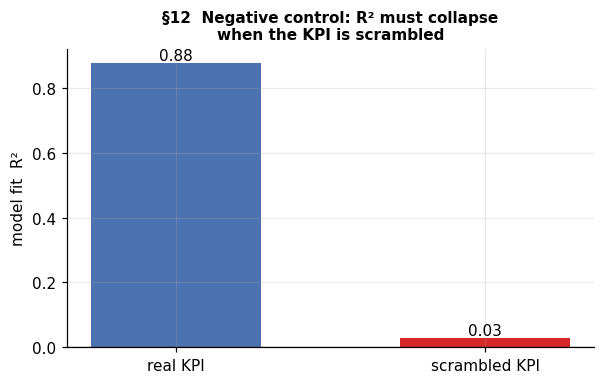

In [29]:
# ── §12 visualization: the negative-control R² must collapse under a scrambled KPI ──
nc = next(t for t in cr.tests if "negative_control" in t.name)
fig, ax = plt.subplots(figsize=(5.6, 3.6))
vals = [nc.original_effect, nc.refuted_effect]
bars = ax.bar(["real KPI", "scrambled KPI"], vals, color=[ACCENT, "#d62728"], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center",
            va="bottom" if v >= 0 else "top", fontsize=10)
ax.axhline(0, color="#333", lw=0.8)
ax.set_ylabel("model fit  R²")
ax.set_title("§12  Negative control: R² must collapse\nwhen the KPI is scrambled",
             fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

## §13 — Causal-assumptions reporting (P0 + P2)

Reports now carry a **Causal Assumptions** section. The extractor auto-populates it
from the model: the confounders it adjusted for, an identification-strategy
statement, and the robustness-value table — so stakeholders see the assumptions the
number rests on, not just its credible interval.

In [30]:
from mmm_framework.reporting.extractors.bayesian import BayesianMMMExtractor
bundle = BayesianMMMExtractor(model).extract()
ca = bundle.causal_assumptions
print("Identification strategy:\n  ", ca["identification_strategy"][:200], "...")
print("\nDesignated confounders (adjusted for):", ca.get("assumed_confounders"))
print("\nRobustness-value table (rendered in the HTML report's Causal Assumptions section):")
display(pd.DataFrame(ca["robustness"]["channels"])[["channel", "robustness_value", "partial_r2", "is_fragile"]].round(3))

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Output()

Sampling: [y_obs]


Output()

Identification strategy:
   Effects are identified by back-door adjustment for the designated confounder(s): Demand. SUTVA and <em>no unobserved</em> confounding are assumed; the estimate is causal only if every common cause of  ...

Designated confounders (adjusted for): ['Demand']

Robustness-value table (rendered in the HTML report's Causal Assumptions section):


,channel,robustness_value,partial_r2,is_fragile
0,TV,0.170,0.033,False
1,Digital,0.258,0.082,False
2,Search,0.182,0.039,False


## Summary

This notebook walked the full causal stack added to `mmm_framework`:

- **Make assumptions explicit & enforce them** — causal role typing (§1),
  identification checks (§2–§3), the causal-assumptions report (§13).
- **Quantify what the number rests on** — unobserved-confounding sensitivity (§6),
  weak-identification (§7) and geo (§8) diagnostics, equifinality guardrails (§9),
  marginal-ROAS uncertainty (§5).
- **Anchor to experiments** — calibrated priors (§11), the in-graph experiment _likelihood_
  (§11b — ROAS/mROAS, every model class), and the refutation suite (§12),
  the levers that actually attack unobserved-demand confounding.
- **Make the process honest** — pre-spec lock + diff (§10).

**Deliberately deferred** (require validation against held-out experiments before
they can change the numbers): geo-heterogeneous media coefficients, grouped-prior
*fitting*, and full Tian–Pearl identification — see
`technical-docs/deferred-causal-features.md`.